MAGALY BENAVIDES SANTIAGO

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [90]:
#DEFINIMOS LAS RUTAS DE ENTRADA
ruta_processed = Path("data/processed")
archivo_clean = ruta_processed / "SPY_2015_2025_clean.csv"
archivo_returns = (ruta_processed / "SPY_2015_2025_returns.csv")

In [91]:
# COMPROBAMOS QUE EXISTA 
if not archivo_clean.exists():
    raise FileNotFoundError(
        f"No se encontro el archivo: {archivo_clean}")

In [92]:
#REALIZAMOS LECTURA DEL CSV Y LO CONVERTIMOS EN UN DATAFRAME
datos_clean = pd.read_csv(archivo_clean, index_col=0, parse_dates=True)
datos = datos_clean.copy(deep=True) # CREA UNA COPIA INDEPENDIENTE

In [93]:
#VERIFICAMOS LA INFORMACION
print(datos.shape)
print(datos.index.min())
print(datos.index.max())
print(datos.columns.tolist())
datos.head(6)

(2766, 6)
2015-01-02 00:00:00
2025-12-31 00:00:00
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,206.380005,206.880005,204.179993,205.429993,169.687836,121465900
2015-01-05,204.169998,204.369995,201.350006,201.720001,166.623337,169632600
2015-01-06,202.089996,202.720001,198.860001,199.820007,165.053909,209151400
2015-01-07,201.419998,202.720001,200.880005,202.309998,167.110703,125346700
2015-01-08,204.009995,206.160004,203.990005,205.899994,170.076080,147217800
2015-01-09,206.399994,206.419998,203.509995,204.250000,168.713120,158567300


# RENDIMIENTO LOGARITMICO

In [94]:
#OBTENEMOS EL RENDIMIENTO LOGARITMICO PRIMERA FORMA
datos["Return"] = np.log(datos["Adj Close"]).diff()
datos['Return'].head(5)

Date
2015-01-02         NaN
2015-01-05   -0.018225
2015-01-06   -0.009464
2015-01-07    0.012384
2015-01-08    0.017589
Name: Return, dtype: float64

In [95]:
#SEGUNDA FROMA DE OBTENER EL RENDIMIENTO
rend_log_alt = np.log(datos["Adj Close"] / datos["Adj Close"].shift(1))
rend_log_alt.head(5)

Date
2015-01-02         NaN
2015-01-05   -0.018225
2015-01-06   -0.009464
2015-01-07    0.012384
2015-01-08    0.017589
Name: Adj Close, dtype: float64

In [96]:
#LAS COMPARAMOS DE ESTA FORMA
comparables = pd.concat( [datos["Return"], rend_log_alt], axis=1).dropna()
assert np.allclose(comparables.iloc[:, 0],comparables.iloc[:, 1])

In [97]:
#OBSERVAMOS QUE HAY UN FALTANTE
print(datos[["Adj Close", "Return"]].head())
print(datos["Return"].isna().sum())

             Adj Close    Return
Date                            
2015-01-02  169.687836       NaN
2015-01-05  166.623337 -0.018225
2015-01-06  165.053909 -0.009464
2015-01-07  167.110703  0.012384
2015-01-08  170.076080  0.017589
1


In [98]:
# COMPROBAMOS QUE EL UNICO VALOR FALTANTE SEA EL PRIMERO
assert datos["Return"].isna().sum() == 1
assert pd.isna(datos["Return"].iloc[0])

OBSERVAMOS QUE NO ES UNA OBSERVACION DE PERDIDA SINO UNA CONSECUENCIA DE UNA DIFERENCIA TEMPORAL

# RENDIMIENTO ABSOLUTO

In [99]:
datos["Return"] = np.log(datos["Adj Close"]).diff()
datos["Return"].head()

Date
2015-01-02         NaN
2015-01-05   -0.018225
2015-01-06   -0.009464
2015-01-07    0.012384
2015-01-08    0.017589
Name: Return, dtype: float64

In [100]:
rend_log_alt = np.log(datos["Adj Close"] / datos["Adj Close"].shift(1))
rend_log_alt.head()

Date
2015-01-02         NaN
2015-01-05   -0.018225
2015-01-06   -0.009464
2015-01-07    0.012384
2015-01-08    0.017589
Name: Adj Close, dtype: float64

In [101]:
comparables = pd.concat([datos["Return"], rend_log_alt], axis=1).dropna()
assert np.allclose(comparables.iloc[:, 0], comparables.iloc[:, 1])

In [102]:
comparables.shift(1) #notamos que hay un faltante 

,Return,Adj Close
Date,,
2015-01-05,NaN,NaN
2015-01-06,-0.018225,-0.018225
2015-01-07,-0.009464,-0.009464
2015-01-08,0.012384,0.012384
2015-01-09,0.017589,0.017589
...,...,...
2025-12-24,0.004560,0.004560
2025-12-26,0.003512,0.003512
2025-12-29,-0.000101,-0.000101


In [103]:
print(datos[["Adj Close", "Return"]].head())
print(datos["Return"].isna().sum())

             Adj Close    Return
Date                            
2015-01-02  169.687836       NaN
2015-01-05  166.623337 -0.018225
2015-01-06  165.053909 -0.009464
2015-01-07  167.110703  0.012384
2015-01-08  170.076080  0.017589
1


In [104]:
assert datos["Return"].isna().sum() == 1
assert pd.isna(datos["Return"].iloc[0])

# RENDIMIENTO ABSOLUTO

In [105]:
datos["Abs_Return"] = datos["Return"].abs()
datos["Abs_Return"].head()

Date
2015-01-02         NaN
2015-01-05    0.018225
2015-01-06    0.009464
2015-01-07    0.012384
2015-01-08    0.017589
Name: Abs_Return, dtype: float64

In [106]:
#RENDIMIENTO AL CUADRADO
datos["Sq_Return"] = datos["Return"] ** 2
datos['Sq_Return'].head()

Date
2015-01-02         NaN
2015-01-05    0.000332
2015-01-06    0.000090
2015-01-07    0.000153
2015-01-08    0.000309
Name: Sq_Return, dtype: float64

CONTRUIMOS UNA TABLA DE COMPARACION


In [107]:
#CONTRUIMOS UNA TABLA CON ADJ CLOSE, RETURN, ABS RETURN, SQ RETURN
#CALCULAMOS LA DIFERENCIA ENTRE RENDIMIENTO SIMPLE Y LOGARITMICO
rend_simple = datos["Adj Close"].pct_change() 
comparacion = pd.DataFrame({'Adj Close': datos['Adj Close'], "Simple": rend_simple, "Logaritmico": datos["Return"],
"Absoluto": datos["Abs_Return"], "Cuadrado": datos["Sq_Return"]})
comparacion["Diferencia:Simple vs log"] = (comparacion["Simple"] - comparacion["Logaritmico"])
comparacion.dropna().head(10)

,Adj Close,Simple,Logaritmico,Absoluto,Cuadrado,Diferencia:Simple vs log
Date,,,,,,
2015-01-05,166.623337,-0.018060,-0.018225,0.018225,0.000332,0.000165
2015-01-06,165.053909,-0.009419,-0.009464,0.009464,0.000090,0.000045
2015-01-07,167.110703,0.012461,0.012384,0.012384,0.000153,0.000077
2015-01-08,170.076080,0.017745,0.017589,0.017589,0.000309,0.000156
2015-01-09,168.713120,-0.008014,-0.008046,0.008046,0.000065,0.000032
2015-01-12,167.391510,-0.007833,-0.007864,0.007864,0.000062,0.000031
2015-01-13,166.920670,-0.002813,-0.002817,0.002817,0.000008,0.000004
2015-01-14,165.912949,-0.006037,-0.006055,0.006055,0.000037,0.000018
2015-01-15,164.393082,-0.009161,-0.009203,0.009203,0.000085,0.000042


In [108]:
#Calcule la diferencia absoluta entre el rendimiento simple y el logarítmico. Identifique la
#fecha en que esa diferencia es máxima.
fecha_max= comparacion["Diferencia:Simple vs log"].idxmax()
max_diferencia = (comparacion['Diferencia:Simple vs log'].abs().max())
print('Fecha:', fecha_max)
print('Diferencia:', max_diferencia)


Fecha: 2020-03-16 00:00:00
Diferencia: 0.0064628211682602466


OBTENEMOS UN RESUMEN DE LAS 3 VARIABLES 

In [109]:
variables = ["Return", "Abs_Return", "Sq_Return"]
resumen = datos[variables].describe(percentiles=[0.01, 0.05, 0.25, 0.75, 0.95, 0.99]).T
resumen

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Return,2765.0,0.000501,0.011232,-0.115887,-3.268429e-02,-1.688546e-02,-0.003712,0.000637,0.005908,0.015474,0.025916,0.099863
Abs_Return,2765.0,0.007318,0.008535,0.000000,7.022591e-05,3.753598e-04,0.001969,0.004925,0.009847,0.021531,0.038402,0.115887
Sq_Return,2765.0,0.000126,0.000512,0.000000,4.939117e-09,1.408955e-07,0.000004,0.000024,0.000097,0.000464,0.001475,0.013430


Si la desviación estándar es mucho mayor que el valor absoluto de la media, una interpretación seria que los rendimientos presentan una dispersión diaria considerablemente mayor que su promedio.

In [110]:
#OBSERVAMOS LA ASIMETRIA DE LA DISTRIBUCION
asimetria = datos["Return"].skew()
curtosis_exceso = datos["Return"].kurt()
print("Asimetria:", asimetria)
print("Exceso de curtosis:", curtosis_exceso)

Asimetria: -0.5833352248951492
Exceso de curtosis: 14.569065924572476


Encuentre los diez rendimientos positivos más grandes y los diez rendimientos negativos más
pequeños.

In [111]:
positivos = (datos.loc[datos["Return"] > 0, "Return"].nlargest(10))
positivos

Date
2025-04-09    0.099863
2020-03-24    0.086731
2020-03-13    0.082028
2020-04-06    0.065007
2020-03-26    0.056749
2022-11-10    0.053497
2020-03-17    0.052585
2020-03-10    0.050451
2018-12-26    0.049290
2020-03-02    0.042395
Name: Return, dtype: float64

In [112]:
negativos = (datos.loc[datos["Return"] < 0, "Return"].nsmallest(10))
negativos

Date
2020-03-16   -0.115887
2020-03-12   -0.100569
2020-03-09   -0.081313
2025-04-04   -0.060326
2020-06-11   -0.059378
2020-03-18   -0.051960
2025-04-03   -0.050537
2020-03-11   -0.049977
2020-04-01   -0.046049
2020-02-27   -0.045951
Name: Return, dtype: float64

VISUALIZAMOS RENDIMIENTOS


Grafique por separado Return, Abs_Return y Sq_Return. Identifique visualmente al menos
dos periodos con movimientos relativamente intensos.

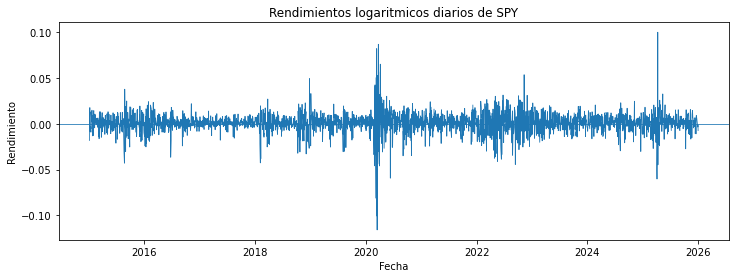

In [113]:
#IDENTIFICAMOS CAMBIOS DE MAGNITUD VARIABLES 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(datos.index, datos["Return"], linewidth=0.8)
ax.axhline(0, linewidth=0.8)
ax.set_title("Rendimientos logaritmicos diarios de SPY")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
plt.show()

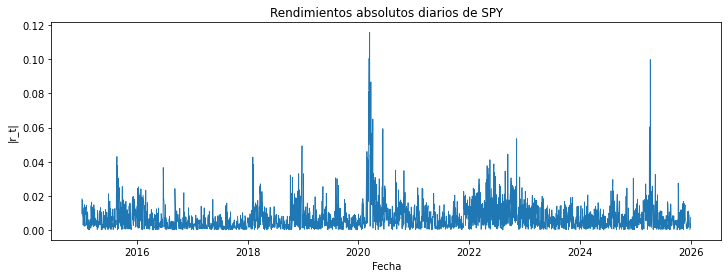

In [114]:
#GRAFICA DE RENDIMIENTOS ABSOLUTOS
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(datos.index, datos["Abs_Return"], linewidth=0.8)
ax.set_title("Rendimientos absolutos diarios de SPY")
ax.set_xlabel("Fecha")
ax.set_ylabel("|r_t|")
plt.show()

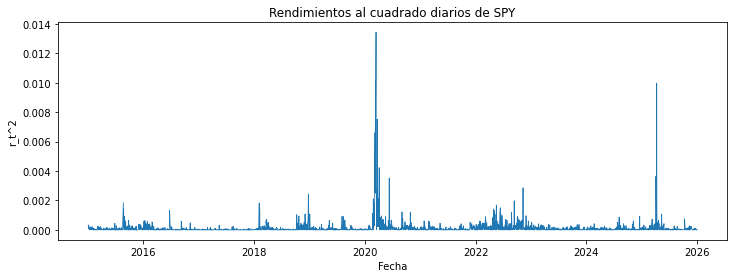

In [115]:
#RENDIMIENTO AL CUADRADO
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(datos.index, datos["Sq_Return"], linewidth=0.8)
ax.set_title("Rendimientos al cuadrado diarios de SPY")
ax.set_xlabel("Fecha")
ax.set_ylabel("r_t^2")
plt.show()

Se identifican dos periodos con mayor concentración de movimientos de magnitud elevada. Estos periodos presentan picos simultáneos en Abs_Return y Sq_Return.
Estan en la fechas de 2020 y 2025

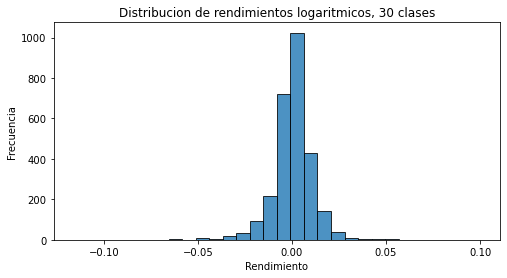

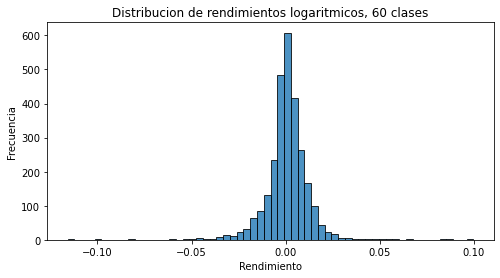

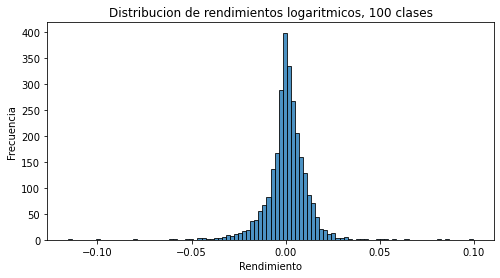

In [116]:
#DISTRIBUCION EMPIRICA
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(datos["Return"].dropna(), bins=30, edgecolor="black", alpha=0.8)
ax.set_title("Distribucion de rendimientos logaritmicos, 30 clases")
ax.set_xlabel("Rendimiento")
ax.set_ylabel("Frecuencia")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(datos["Return"].dropna(), bins=60, edgecolor="black", alpha=0.8)
ax.set_title("Distribucion de rendimientos logaritmicos, 60 clases")
ax.set_xlabel("Rendimiento")
ax.set_ylabel("Frecuencia")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(datos["Return"].dropna(), bins=100, edgecolor="black", alpha=0.8)
ax.set_title("Distribucion de rendimientos logaritmicos, 100 clases")
ax.set_xlabel("Rendimiento")
ax.set_ylabel("Frecuencia")

plt.show()

NOTAMOS QUE LAS BARRAS DE ACUERDO AL NUMERO DE CLASES, ESTAS SE VUELVEN MAS DETALLADAS, AUNQUE SU DISTRIBUCION SE CONSERVA IGUAL, OBSERVAMOS QUE LA CONCENTRACION DE MUCHOS RENDIMIENTOS CERCA DE CERO Y SE MANTIENE LAS COLAS HACIA RENDIMIENTOS POSITIVOS Y NEGATIVOS.

In [117]:
# IDENTIFICACION DE MAYORES MOVIMIENTOS
mayores_movimientos = (datos[["Adj Close","Return","Abs_Return","Sq_Return"]].dropna()
.nlargest(10, "Abs_Return"))
mayores_movimientos

,Adj Close,Return,Abs_Return,Sq_Return
Date,,,,
2020-03-16,218.627914,-0.115887,0.115887,0.013430
2020-03-12,226.157089,-0.100569,0.100569,0.010114
2025-04-09,541.008362,0.099863,0.099863,0.009973
2020-03-24,222.939194,0.086731,0.086731,0.007522
2020-03-13,245.490433,0.082028,0.082028,0.006729
2020-03-09,249.965958,-0.081313,0.081313,0.006612
2020-04-06,242.844666,0.065007,0.065007,0.004226
2025-04-04,498.269684,-0.060326,0.060326,0.003639
2020-06-11,275.623047,-0.059378,0.059378,0.003526


# VALIDACIONES AUTOMATICAS

NO NEGATIVIDAD

In [118]:
validos = datos["Return"].notna()
assert (datos.loc[validos, "Abs_Return"] >= 0).all()
assert(datos.loc[validos, "Sq_Return"] >= 0).all()

CONSISTENCIA CON LAS DEFINICION

In [119]:
assert np.allclose(datos.loc[validos, "Abs_Return"], np.abs(datos.loc[validos, "Return"]))
assert np.allclose(datos.loc[validos, "Sq_Return"], datos.loc[validos, "Return"] ** 2)

VALORES FINITOS

In [120]:
assert np.isfinite(datos.loc[validos, "Return"]).all()

# CONTRUCCION DE LA BASE FINAL

In [121]:
datos_returns = datos.dropna(subset=["Return","Abs_Return","Sq_Return"]).copy()
datos_returns.head()


,Open,High,Low,Close,Adj Close,Volume,Return,Abs_Return,Sq_Return
Date,,,,,,,,,
2015-01-05,204.169998,204.369995,201.350006,201.720001,166.623337,169632600,-0.018225,0.018225,0.000332
2015-01-06,202.089996,202.720001,198.860001,199.820007,165.053909,209151400,-0.009464,0.009464,0.000090
2015-01-07,201.419998,202.720001,200.880005,202.309998,167.110703,125346700,0.012384,0.012384,0.000153
2015-01-08,204.009995,206.160004,203.990005,205.899994,170.076080,147217800,0.017589,0.017589,0.000309
2015-01-09,206.399994,206.419998,203.509995,204.250000,168.713120,158567300,-0.008046,0.008046,0.000065


BASE FINAL

In [125]:
columnas_finales = ["Open","High","Low", "Close", "Adj Close", "Volume", "Return", "Abs_Return", "Sq_Return"]
datos_returns = datos_returns[columnas_finales]
datos_returns

,Open,High,Low,Close,Adj Close,Volume,Return,Abs_Return,Sq_Return
Date,,,,,,,,,
2015-01-05,204.169998,204.369995,201.350006,201.720001,166.623337,169632600,-0.018225,0.018225,3.321394e-04
2015-01-06,202.089996,202.720001,198.860001,199.820007,165.053909,209151400,-0.009464,0.009464,8.956073e-05
2015-01-07,201.419998,202.720001,200.880005,202.309998,167.110703,125346700,0.012384,0.012384,1.533718e-04
2015-01-08,204.009995,206.160004,203.990005,205.899994,170.076080,147217800,0.017589,0.017589,3.093865e-04
2015-01-09,206.399994,206.419998,203.509995,204.250000,168.713120,158567300,-0.008046,0.008046,6.473994e-05
...,...,...,...,...,...,...,...,...,...
2025-12-24,687.950012,690.830017,687.799988,690.380005,686.730530,39445600,0.003512,0.003512,1.233065e-05
2025-12-26,690.640015,691.659973,689.270020,690.309998,686.660889,41613300,-0.000101,0.000101,1.028496e-08
2025-12-29,687.539978,689.200012,686.070007,687.849976,684.213867,62559500,-0.003570,0.003570,1.274503e-05


In [126]:
# EXPORTACION DE LA BASE
datos_returns.to_csv(archivo_returns,index=True)

In [127]:
verificacion = pd.read_csv(archivo_returns,index_col=0,parse_dates=True)
assert verificacion.shape == datos_returns.shape
assert verificacion.index.is_monotonic_increasing
assert not verificacion["Return"].isna().any()